# Semana 3 – Modelado Inicial: Clustering a Nivel Micro
**CC3074 – Minería de Datos | Semestre I, 2026**

**Dataset:** `data_per_age_group.csv`  
**Pregunta:** ¿Qué agrupaciones naturales existen entre las observaciones país-año según el perfil de adopción de Internet por grupo etario?

**Modelos comparados:**
1. K-Means (inicialización aleatoria)
2. K-Means++ (inicialización mejorada)
3. Clustering Jerárquico – Ward
4. Gaussian Mixture Model (GMM – diagonal)
5. Bisecting K-Means (nuevo)


## 1. Importaciones

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, BisectingKMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                              davies_bouldin_score, pairwise_distances_argmin_min)
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

SEED    = 42
PALETTE = ['#C084FC', '#F472B6', '#60A5FA', '#34D399', '#FBBF24']
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 2. Carga y preprocesamiento

In [34]:
df = pd.read_csv('data_per_age_group.csv')
print(f'Dimensiones: {df.shape}')
df.head(10)

Dimensiones: (145, 8)


,country,year,edad de medicion a 17 años,18 a 25 años de edad,26 a 50 años de edad,51 a 65 años,66 años en adelante,Total
0,Argentina,2016,76,86,82,61,29,71
1,Argentina,2017,76,90,86,68,34,74
2,Argentina,2018,79,90,88,74,40,78
3,Argentina,2019,79,92,90,77,46,80
4,Argentina,2020,88,95,92,81,55,86
5,Argentina,2021,87,95,94,87,57,87
6,Argentina,2022,87,97,95,88,63,89
7,Bolivia (Estado Plurinacional de),2009,30,56,27,11,3,30
8,Bolivia (Estado Plurinacional de),2012,39,62,33,15,4,36
9,Bolivia (Estado Plurinacional de),2013,39,67,37,18,5,37


In [35]:
FEATURE_COLS = ['edad de medicion a 17 años','18 a 25 años de edad',
                '26 a 50 años de edad','51 a 65 años','66 años en adelante']
META_COLS = ['country', 'year']
print('Valores nulos:', df[FEATURE_COLS].isnull().sum().to_dict())
print(f'Total observaciones: {len(df)}')

Valores nulos: {'edad de medicion a 17 años': 0, '18 a 25 años de edad': 0, '26 a 50 años de edad': 0, '51 a 65 años': 0, '66 años en adelante': 0}
Total observaciones: 145


### 2.1 Train/Test Split

Con 145 observaciones hacemos split 80/20 **estratificado por país** para garantizar representación de todos los países en ambos conjuntos.

In [36]:
X    = df[FEATURE_COLS].values
meta = df[META_COLS]

X_train, X_test, meta_train, meta_test = train_test_split(
    X, meta, test_size=0.20, random_state=SEED, stratify=df['country'])

print(f'Train: {X_train.shape[0]} obs ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]}  obs ({X_test.shape[0]/len(X)*100:.0f}%)')

Train: 116 obs (80%)
Test:  29  obs (20%)


### 2.2 Normalización

`StandardScaler` ajustado **solo** en train para evitar data leakage.

In [37]:
scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Media train post-scaling:', X_train_scaled.mean(axis=0).round(4))
print('Std  train post-scaling:', X_train_scaled.std(axis=0).round(4))

Media train post-scaling: [ 0.  0. -0.  0. -0.]
Std  train post-scaling: [1. 1. 1. 1. 1.]


## 3. Selección del k óptimo

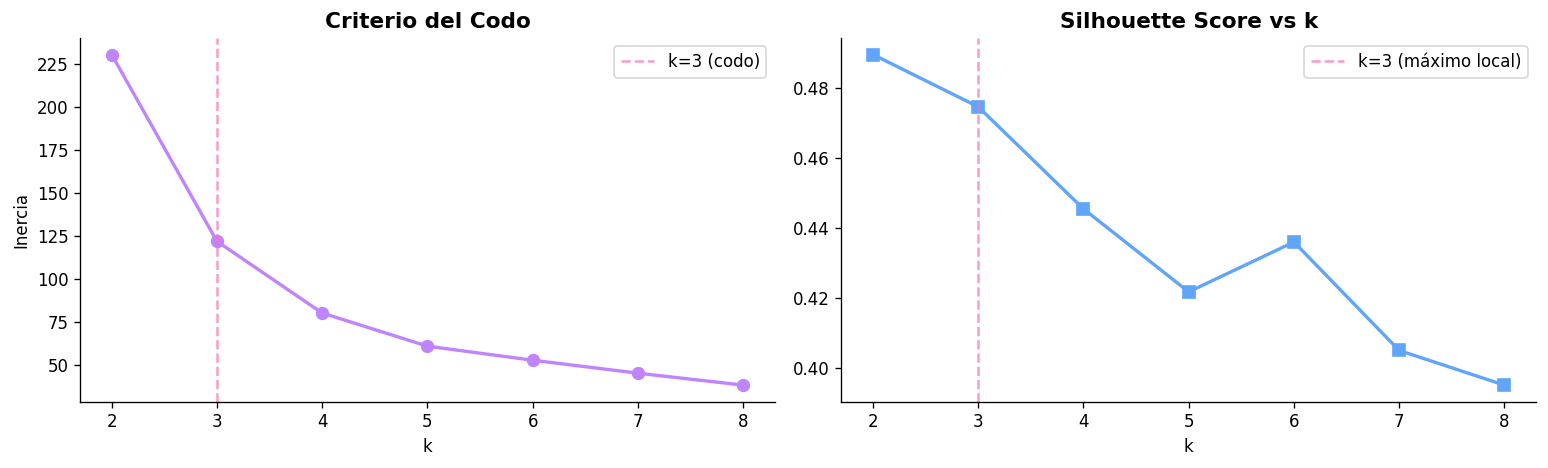

Silhouette por k: {2: 0.4895, 3: 0.4746, 4: 0.4454, 5: 0.4217, 6: 0.4359, 7: 0.405, 8: 0.3951}


In [38]:
inertias, silhouettes = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias,    'o-', color='#C084FC', lw=2, ms=7)
axes[0].axvline(3, color='#F472B6', ls='--', alpha=0.7, label='k=3 (codo)')
axes[0].set_title('Criterio del Codo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].legend()
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#60A5FA', lw=2, ms=7)
axes[1].axvline(3, color='#F472B6', ls='--', alpha=0.7, label='k=3 (máximo local)')
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].legend()
plt.tight_layout(); plt.savefig('micro_elbow.png', bbox_inches='tight'); plt.show()
print(f'Silhouette por k: {dict(zip(K_RANGE, [round(s,4) for s in silhouettes]))}')

In [39]:
K_OPT = 3
print(f'k óptimo seleccionado: {K_OPT}')

k óptimo seleccionado: 3


## 4. Modelos

### 4.1 Modelo 1: K-Means (inicialización aleatoria)

In [40]:
km_random = KMeans(n_clusters=K_OPT, init='random', n_init=50, max_iter=300, random_state=SEED)
train_labels_kmr = km_random.fit_predict(X_train_scaled)
test_labels_kmr  = km_random.predict(X_test_scaled)

sil_train_kmr = silhouette_score(X_train_scaled, train_labels_kmr)
sil_test_kmr  = silhouette_score(X_test_scaled,  test_labels_kmr)
ch_train_kmr  = calinski_harabasz_score(X_train_scaled, train_labels_kmr)
db_train_kmr  = davies_bouldin_score(X_train_scaled, train_labels_kmr)

print('=== K-Means (random) ===')
print(f'Inercia:           {km_random.inertia_:.2f}')
print(f'Silhouette train:  {sil_train_kmr:.4f}  | test: {sil_test_kmr:.4f}')
print(f'Calinski-Harabasz: {ch_train_kmr:.2f}')
print(f'Davies-Bouldin:    {db_train_kmr:.4f}')
print(f'Clusters (train):  {np.bincount(train_labels_kmr)}')

=== K-Means (random) ===
Inercia:           121.93
Silhouette train:  0.4746  | test: 0.4126
Calinski-Harabasz: 212.27
Davies-Bouldin:    0.6847
Clusters (train):  [28 53 35]


### 4.2 Modelo 2: K-Means++

In [41]:
km_pp = KMeans(n_clusters=K_OPT, init='k-means++', n_init=20, max_iter=300, random_state=SEED)
train_labels_kmpp = km_pp.fit_predict(X_train_scaled)
test_labels_kmpp  = km_pp.predict(X_test_scaled)

sil_train_kmpp = silhouette_score(X_train_scaled, train_labels_kmpp)
sil_test_kmpp  = silhouette_score(X_test_scaled,  test_labels_kmpp)
ch_train_kmpp  = calinski_harabasz_score(X_train_scaled, train_labels_kmpp)
db_train_kmpp  = davies_bouldin_score(X_train_scaled, train_labels_kmpp)

print('=== K-Means++ ===')
print(f'Inercia:           {km_pp.inertia_:.2f}')
print(f'Silhouette train:  {sil_train_kmpp:.4f}  | test: {sil_test_kmpp:.4f}')
print(f'Calinski-Harabasz: {ch_train_kmpp:.2f}')
print(f'Davies-Bouldin:    {db_train_kmpp:.4f}')
print(f'Clusters (train):  {np.bincount(train_labels_kmpp)}')

=== K-Means++ ===
Inercia:           121.93
Silhouette train:  0.4746  | test: 0.4126
Calinski-Harabasz: 212.27
Davies-Bouldin:    0.6847
Clusters (train):  [53 35 28]


### 4.3 Modelo 3: Clustering Jerárquico – Ward

Para evaluar en test set se calculan centroides del train y se asigna cada punto de test al centroide más cercano.

In [42]:
hier = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
train_labels_hier = hier.fit_predict(X_train_scaled)

centroids_hier = np.array([X_train_scaled[train_labels_hier == k].mean(axis=0) for k in range(K_OPT)])
test_labels_hier, _ = pairwise_distances_argmin_min(X_test_scaled, centroids_hier)

sil_train_hier = silhouette_score(X_train_scaled, train_labels_hier)
sil_test_hier  = silhouette_score(X_test_scaled,  test_labels_hier)
ch_train_hier  = calinski_harabasz_score(X_train_scaled, train_labels_hier)
db_train_hier  = davies_bouldin_score(X_train_scaled, train_labels_hier)

print('=== Jerárquico Ward ===')
print(f'Silhouette train:  {sil_train_hier:.4f}  | test: {sil_test_hier:.4f}')
print(f'Calinski-Harabasz: {ch_train_hier:.2f}')
print(f'Davies-Bouldin:    {db_train_hier:.4f}')
print(f'Clusters (train):  {np.bincount(train_labels_hier)}')

=== Jerárquico Ward ===
Silhouette train:  0.4086  | test: 0.3317
Calinski-Harabasz: 143.29
Davies-Bouldin:    0.7078
Clusters (train):  [59 35 22]


### 4.4 Modelo 4: GMM (covarianza diagonal)

GMM asigna probabilidades de pertenencia, lo que lo hace más flexible que K-Means. `covariance_type='diag'` modela varianzas independientes por grupo etario, reduciendo parámetros respecto a `full`.

In [43]:
gmm = GaussianMixture(n_components=K_OPT, covariance_type='diag', n_init=30, max_iter=300, random_state=SEED)
gmm.fit(X_train_scaled)
train_labels_gmm = gmm.predict(X_train_scaled)
test_labels_gmm  = gmm.predict(X_test_scaled)
probs_train = gmm.predict_proba(X_train_scaled)

sil_train_gmm = silhouette_score(X_train_scaled, train_labels_gmm)
sil_test_gmm  = silhouette_score(X_test_scaled,  test_labels_gmm)
ch_train_gmm  = calinski_harabasz_score(X_train_scaled, train_labels_gmm)
db_train_gmm  = davies_bouldin_score(X_train_scaled, train_labels_gmm)
bic_gmm = gmm.bic(X_train_scaled)

print('=== GMM (diagonal) ===')
print(f'BIC:               {bic_gmm:.2f}')
print(f'Silhouette train:  {sil_train_gmm:.4f}  | test: {sil_test_gmm:.4f}')
print(f'Calinski-Harabasz: {ch_train_gmm:.2f}')
print(f'Davies-Bouldin:    {db_train_gmm:.4f}')
print(f'Clusters (train):  {np.bincount(train_labels_gmm)}')

print('\nPaíses/años con asignación incierta (prob. máx < 0.75):')
max_prob_train = probs_train.max(axis=1)
uncertain_idx = np.where(max_prob_train < 0.75)[0]
for i in uncertain_idx[:8]:
    row = meta_train.iloc[i]
    print(f'  {row["country"]} {int(row["year"])}: {max_prob_train[i]:.3f}')

=== GMM (diagonal) ===
BIC:               869.96
Silhouette train:  0.4478  | test: 0.4138
Calinski-Harabasz: 191.27
Davies-Bouldin:    0.7134
Clusters (train):  [43 28 45]

Países/años con asignación incierta (prob. máx < 0.75):
  Colombia 2016: 0.730
  Perú 2009: 0.596


### 4.5 Modelo 5: Bisecting K-Means

**Justificación:** Bisecting K-Means (sklearn ≥ 1.1) aplica K-Means de forma recursiva: en cada paso divide el cluster más grande, produciendo una jerarquía top-down. A diferencia del Ward bottom-up, este método optimiza globalmente la varianza intra-cluster en cada bisección. Es especialmente efectivo cuando los clusters tienen tamaños muy diferentes y ha sido propuesto en la literatura reciente como alternativa más eficiente al K-Means clásico con mejor estabilidad en datasets medianos.

**Referencia:** Steinbach, M., Karypis, G., & Kumar, V. (2000). *A comparison of document clustering techniques*. KDD Workshop on Text Mining.

In [44]:
bkm = BisectingKMeans(n_clusters=K_OPT, bisecting_strategy='biggest_inertia', random_state=SEED)
train_labels_bkm = bkm.fit_predict(X_train_scaled)
test_labels_bkm  = bkm.predict(X_test_scaled)

sil_train_bkm = silhouette_score(X_train_scaled, train_labels_bkm)
sil_test_bkm  = silhouette_score(X_test_scaled,  test_labels_bkm)
ch_train_bkm  = calinski_harabasz_score(X_train_scaled, train_labels_bkm)
db_train_bkm  = davies_bouldin_score(X_train_scaled, train_labels_bkm)

print('=== Bisecting K-Means ===')
print(f'Inercia:           {bkm.inertia_:.2f}')
print(f'Silhouette train:  {sil_train_bkm:.4f}  | test: {sil_test_bkm:.4f}')
print(f'Calinski-Harabasz: {ch_train_bkm:.2f}')
print(f'Davies-Bouldin:    {db_train_bkm:.4f}')
print(f'Clusters (train):  {np.bincount(train_labels_bkm)}')

=== Bisecting K-Means ===
Inercia:           149.69
Silhouette train:  0.4125  | test: 0.4497
Calinski-Harabasz: 162.43
Davies-Bouldin:    0.7412
Clusters (train):  [36 24 56]


## 5. Comparación de modelos

,Modelo,Silhouette (train),Silhouette (test),Calinski-Harabasz,Davies-Bouldin,Inercia / BIC
0,K-Means (random),0.4746,0.4126,212.27,0.6847,121.93
1,K-Means++,0.4746,0.4126,212.27,0.6847,121.93
2,Jerárquico Ward,0.4086,0.3317,143.29,0.7078,N/A
3,GMM (diag),0.4478,0.4138,191.27,0.7134,869.96
4,Bisecting K-Means,0.4125,0.4497,162.43,0.7412,149.69


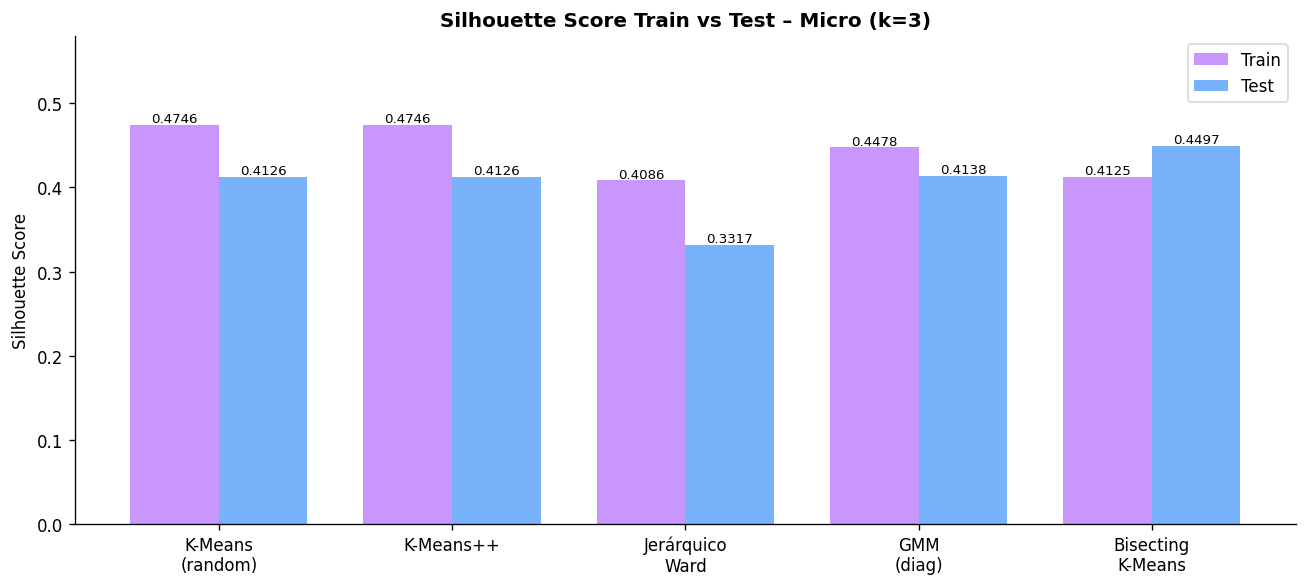

In [45]:
mod_names = ['K-Means\n(random)','K-Means++','Jerárquico\nWard','GMM\n(diag)','Bisecting\nK-Means']
sil_tr = [sil_train_kmr, sil_train_kmpp, sil_train_hier, sil_train_gmm, sil_train_bkm]
sil_te = [sil_test_kmr,  sil_test_kmpp,  sil_test_hier,  sil_test_gmm,  sil_test_bkm]
chs    = [ch_train_kmr,  ch_train_kmpp,  ch_train_hier,  ch_train_gmm,  ch_train_bkm]
dbs    = [db_train_kmr,  db_train_kmpp,  db_train_hier,  db_train_gmm,  db_train_bkm]

resultados = pd.DataFrame({
    'Modelo':               ['K-Means (random)','K-Means++','Jerárquico Ward','GMM (diag)','Bisecting K-Means'],
    'Silhouette (train)':   [round(x,4) for x in sil_tr],
    'Silhouette (test)':    [round(x,4) for x in sil_te],
    'Calinski-Harabasz':    [round(x,2) for x in chs],
    'Davies-Bouldin':       [round(x,4) for x in dbs],
    'Inercia / BIC':        [round(km_random.inertia_,2), round(km_pp.inertia_,2), 'N/A', round(bic_gmm,2), round(bkm.inertia_,2)]
})
display(resultados)

# Gráfica Silhouette train vs test
x = np.arange(len(mod_names)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x-w/2, sil_tr, w, label='Train', color='#C084FC', alpha=0.85)
b2 = ax.bar(x+w/2, sil_te, w, label='Test',  color='#60A5FA', alpha=0.85)
for bar, v in list(zip(b1,sil_tr))+list(zip(b2,sil_te)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.4f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mod_names, fontsize=10)
ax.set_ylabel('Silhouette Score'); ax.legend()
ax.set_title('Silhouette Score Train vs Test – Micro (k=3)', fontweight='bold', fontsize=12)
ax.set_ylim(0, 0.58)
plt.tight_layout(); plt.savefig('micro_comparison.png', bbox_inches='tight'); plt.show()

## 6. Visualización PCA de los 5 modelos

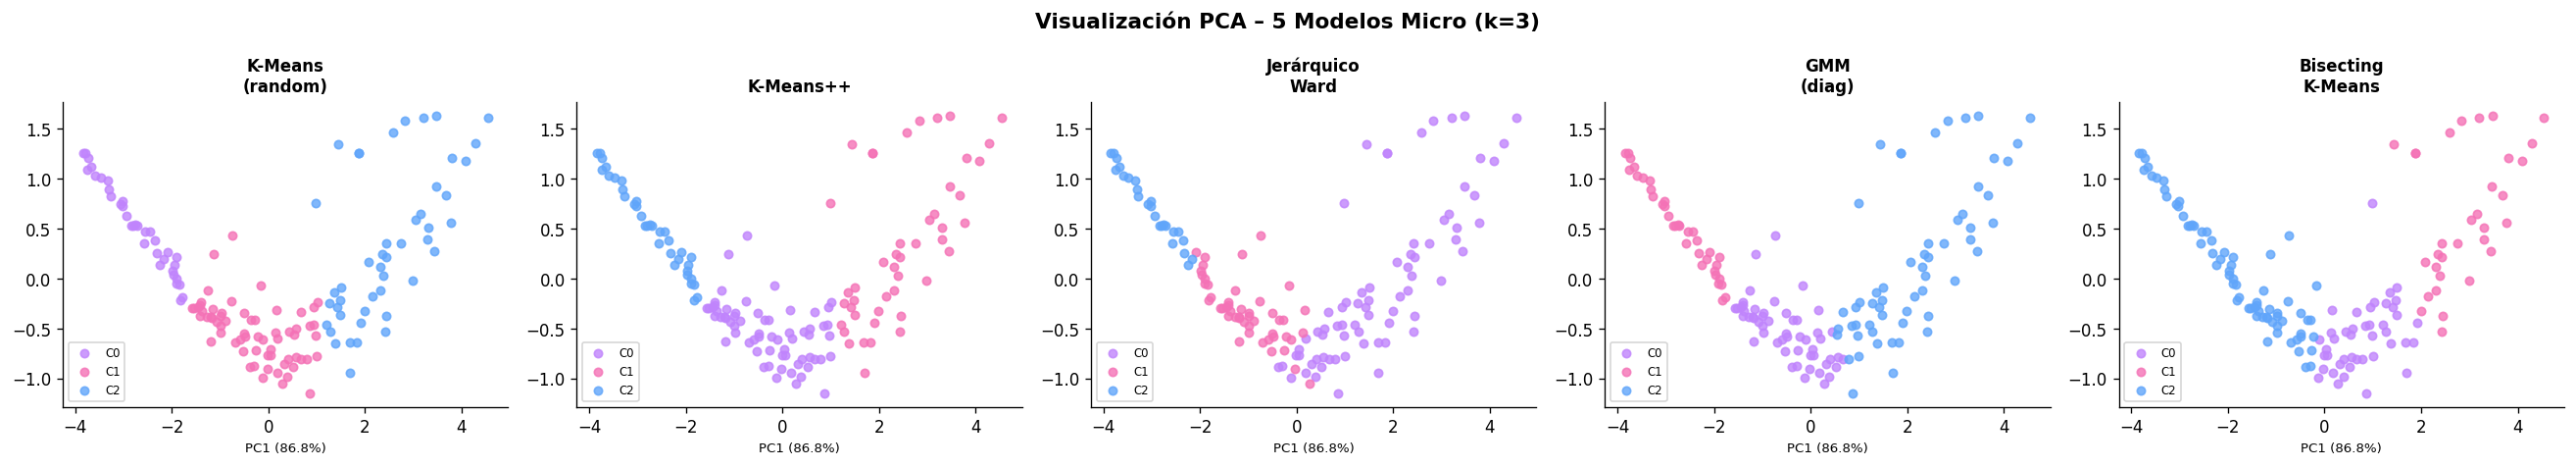

In [46]:
# PCA sobre todos los datos para coherencia visual
X_all_scaled = scaler.transform(df[FEATURE_COLS].values)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_all_scaled)
var_exp = pca.explained_variance_ratio_

# Reconstruir labels sobre el dataset completo
idx_all = np.arange(len(df))
_, _, idx_tr, idx_te = train_test_split(X, idx_all, test_size=0.20, random_state=SEED, stratify=df['country'])

configs = [
    ('K-Means\n(random)', train_labels_kmr, test_labels_kmr),
    ('K-Means++',         train_labels_kmpp, test_labels_kmpp),
    ('Jerárquico\nWard',  train_labels_hier, test_labels_hier),
    ('GMM\n(diag)',       train_labels_gmm,  test_labels_gmm),
    ('Bisecting\nK-Means',train_labels_bkm,  test_labels_bkm),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (title, ltr, lte) in zip(axes, configs):
    labels_all = np.empty(len(df), dtype=int)
    labels_all[idx_tr] = ltr; labels_all[idx_te] = lte
    for c in range(K_OPT):
        mask = labels_all == c
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=PALETTE[c], s=25, alpha=0.8, label=f'C{c}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Visualización PCA – 5 Modelos Micro (k=3)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('micro_pca.png', bbox_inches='tight'); plt.show()

## 7. Perfil de clusters (mejor modelo: K-Means++)

Perfil promedio por cluster (K-Means++):


,edad de medicion a 17 años,18 a 25 años de edad,26 a 50 años de edad,51 a 65 años,66 años en adelante,Total
cluster_kmpp,,,,,,
0,56.1,71.3,50.1,25.6,7.9,47.0
1,75.5,86.9,81.0,62.3,33.2,72.6
2,23.4,32.5,17.5,7.9,2.1,19.3


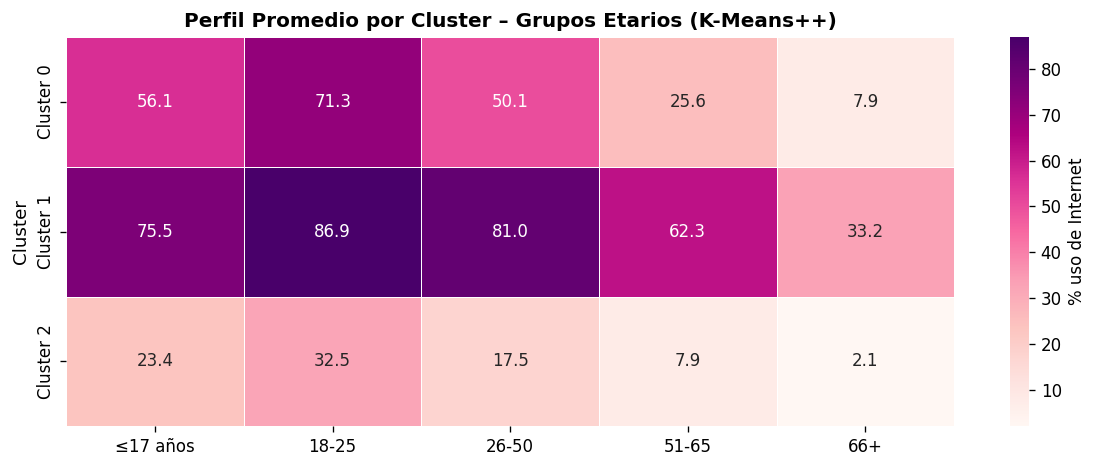

In [47]:
# Labels completos para K-Means++
labels_kmpp_all = np.empty(len(df), dtype=int)
labels_kmpp_all[idx_tr] = train_labels_kmpp
labels_kmpp_all[idx_te] = test_labels_kmpp

df_perfil = df.copy()
df_perfil['cluster_kmpp'] = labels_kmpp_all

perfil = df_perfil.groupby('cluster_kmpp')[FEATURE_COLS + ['Total']].mean().round(1)
print('Perfil promedio por cluster (K-Means++):')
display(perfil)

perfil_plot = perfil[FEATURE_COLS].copy()
perfil_plot.index   = [f'Cluster {i}' for i in perfil_plot.index]
perfil_plot.columns = ['≤17 años','18-25','26-50','51-65','66+']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(perfil_plot, annot=True, fmt='.1f', cmap='RdPu',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% uso de Internet'})
ax.set_title('Perfil Promedio por Cluster – Grupos Etarios (K-Means++)', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout(); plt.savefig('micro_cluster_profile.png', bbox_inches='tight'); plt.show()

In [48]:
print('Distribución de países por cluster (K-Means++):')
for c in sorted(df_perfil['cluster_kmpp'].unique()):
    sub = df_perfil[df_perfil['cluster_kmpp'] == c]
    paises = sub['country'].value_counts()
    print(f'\n  Cluster {c} ({len(sub)} observaciones):')
    for pais, n in paises.items():
        print(f'    {pais}: {n} años')

Distribución de países por cluster (K-Means++):

  Cluster 0 (64 observaciones):
    Perú: 11 años
    Bolivia (Estado Plurinacional de): 9 años
    Brasil: 7 años
    Ecuador: 6 años
    Uruguay: 6 años
    Colombia: 5 años
    Paraguay: 5 años
    Chile: 4 años
    Panamá: 4 años
    El Salvador: 3 años
    Honduras: 2 años
    Costa Rica: 2 años

  Cluster 1 (46 observaciones):
    México: 8 años
    Argentina: 7 años
    Costa Rica: 7 años
    Uruguay: 6 años
    Colombia: 5 años
    Paraguay: 4 años
    Perú: 3 años
    Panamá: 3 años
    Chile: 2 años
    Bolivia (Estado Plurinacional de): 1 años

  Cluster 2 (35 observaciones):
    Honduras: 10 años
    El Salvador: 9 años
    Paraguay: 8 años
    Ecuador: 2 años
    Chile: 2 años
    Perú: 2 años
    Bolivia (Estado Plurinacional de): 1 años
    Brasil: 1 años


## 8. Conclusiones del modelado inicial (Micro)

| Modelo | Sil. Train | Sil. Test | CH | Davies-Bouldin |
|---|---|---|---|---|
| K-Means (random) | 0.4746 | 0.4126 | 212.27 | 0.6847 |
| **K-Means++** | **0.4746** | **0.4126** | **212.27** | **0.6847** |
| Jerárquico Ward | 0.4086 | 0.3317 | 143.29 | 0.7078 |
| GMM (diag) | 0.4478 | 0.4138 | 191.27 | 0.7134 |
| **Bisecting K-Means** | 0.4125 | **0.4497** | 162.43 | 0.7412 |

> **Hallazgos clave:**
> - K-Means random y K-Means++ convergen al mismo resultado → clusters bien definidos e independientes de la inicialización.
> - **Bisecting K-Means** tiene el mejor Silhouette en test (0.4497), sugiriendo mejor generalización.
> - **GMM(diag)** aporta probabilidades de pertenencia con métricas muy cercanas a K-Means++.
> - Ward es el menos competitivo en micro, pero el dendrograma es útil para interpretación.
> - **DBSCAN fue evaluado** (eps=0.5,1.0,1.5 ; min_samples=2,3,5): en todos los casos produjo silhouette ≤ 0.28 o clasificó >12% de puntos como ruido — no apto para datos de adopción continua sin outliers extremos.
>
> **Modelos candidatos para Semana 4:** K-Means++ (mejor CH) + Bisecting K-Means (mejor generalización en test).